# Machine Learning for Return Prediction

---

**🎯 Learning Objectives**

By the end of this chapter, you should be able to:

1. **Frame the return prediction problem** as function approximation: $R_{t+1} = F(X_t) + \varepsilon$, where signal is tiny relative to noise.
2. **Explain the bias-variance tradeoff** and why it is especially severe for financial returns (low signal-to-noise ratio).
3. **Apply regularized linear models** (Lasso, Elastic Net) to select among hundreds of noisy characteristics.
4. **Use tree-based methods** (Random Forest, Gradient Boosting) to capture non-linearities and interactions automatically.
5. **Build and regularize neural networks** for return prediction, using dropout, weight decay, and early stopping.
6. **Compare models rigorously** using out-of-sample evaluation with proper time-series discipline (no future information leakage).

## Libraries and Auxiliary Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, ElasticNet, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## The Problem: Predicting Returns with Many Characteristics

We want to estimate a function $F$ that maps observable firm characteristics to future returns:

$$R_{i,t+1} = F(X_{i,t}) + \varepsilon_{i,t+1}$$

In the cross-sectional regression chapter, we ran OLS of returns on roughly 30 characteristics. That is a reasonable starting point, but it ignores a lot of potentially useful structure:

- **Interactions.** Value might predict returns differently for small stocks than for large stocks. With 30 characteristics, pairwise interactions alone add $\binom{30}{2} = 435$ additional coefficients. Add squared terms and you are at roughly 900. Include lags of characteristics and the count grows further.
- **Non-linearities.** The relationship between a characteristic and expected returns may not be linear. Perhaps only the extreme deciles of momentum matter, or there is a threshold effect in leverage.

The fundamental challenge is that the **signal-to-noise ratio in return prediction is extremely low**. Monthly individual stock return volatility is roughly 10%, but the predictable component of the cross-section might be only 0.1--0.5% per month. Out-of-sample $R^2$ values of 0.1--0.5% monthly are economically meaningful (they can generate significant Sharpe ratios when applied to large cross-sections of stocks) but statistically tiny.

This is the opposite of domains like image classification or natural language processing, where the signal is strong and deep models achieve $R^2$ above 90%. In finance, **overfitting is the central danger**: a model that is slightly better at capturing signal but much worse at ignoring noise will fail out of sample.

The function $F$ can take many forms:
- **Linear:** $R_{i,t+1} = \beta' X_{i,t}$
- **Linear in interactions:** $R_{i,t+1} = \beta' X_{i,t} + \gamma' (X_{i,t} \otimes X_{i,t})$
- **Fully non-linear:** learned by trees, neural networks, etc.

Machine learning provides tools to estimate flexible forms of $F$ while controlling overfitting through **regularization** — the systematic introduction of bias to reduce variance.

> **📌 Remember:** An $R^2$ of 0.1% per month sounds tiny, but applied to thousands of stocks it can generate Sharpe ratios above 2. The bar for economic significance is very different from statistical significance.

### Our roadmap

We progress from simple to complex:

1. **Linear models + regularization** (Lasso, Elastic Net) — shrink and select among raw characteristics
2. **Tree-based methods** (Random Forest, Gradient Boosting) — capture interactions and non-linearities without manual feature engineering
3. **Neural networks** — maximum flexibility, but maximum overfitting risk

At each step, we trade off **bias** (model too simple to capture the true pattern) versus **variance** (model flexible enough to fit noise). In finance, variance almost always dominates — simpler models often win out of sample.

We use a fixed time-series split:
- **Training:** 1972–1991
- **Tuning:** 1992–2001
- A held-out test sample (2002–2016) is available but we will not use it today.

> **⚠️ Caution:** Never shuffle time-series data for cross-validation. The tuning sample must always come *after* the training sample. Using future data to predict the past is the single most common mistake in financial ML.

## Data

In [2]:
url_train = "https://github.com/amoreira2/Fin418/blob/main/assets/data/characteristics19721991.pkl?raw=true"
url_tune = "https://github.com/amoreira2/Fin418/blob/main/assets/data/characteristics19922001.pkl?raw=true"

df_train = pd.read_pickle(url_train).drop(columns=['rf', 'rme'])
df_tuning = pd.read_pickle(url_tune).drop(columns=['rf', 'rme'])

Y_train = df_train.iloc[:, 0]  # excess returns
Y_tuning = df_tuning.iloc[:, 0]

# Cross-sectional standardization (zero mean, unit std each month)
X_train = df_train.iloc[:, 1:].groupby('date').transform(lambda x: (x - x.mean()) / x.std())
X_tuning = df_tuning.iloc[:, 1:].groupby('date').transform(lambda x: (x - x.mean()) / x.std())

print(f"Training sample: {X_train.shape[0]:,} stock-months, {X_train.shape[1]} characteristics")
print(f"Tuning sample:   {X_tuning.shape[0]:,} stock-months")
print(f"\nCharacteristics: {list(X_train.columns)}")

Training sample: 204,284 stock-months, 29 characteristics
Tuning sample:   99,615 stock-months

Characteristics: ['size', 'value', 'prof', 'fscore', 'debtiss', 'repurch', 'nissa', 'growth', 'aturnover', 'gmargins', 'ep', 'sgrowth', 'lev', 'roaa', 'roea', 'sp', 'mom', 'indmom', 'mom12', 'momrev', 'valuem', 'nissm', 'strev', 'ivol', 'betaarb', 'indrrev', 'price', 'age', 'shvol']


## A Laboratory for Machine Learning

With real returns, we never know the true expected return function — so we can't tell whether a model fails because of estimation error or because the signal doesn't exist.

To build intuition, we construct **synthetic returns** with a known signal embedded in real noise:

$$\tilde{R}_{i,t} = \alpha \cdot \lambda' X_{i,t} + \varepsilon_{i,t}$$

- $X_{i,t}$: actual standardized characteristics
- $\varepsilon_{i,t}$: demeaned actual returns (preserves real factor structure and cross-sectional dependence)
- $\lambda$: known weight vector — we choose which characteristics predict returns
- $\alpha$: signal strength — controls the signal-to-noise ratio

This lets us evaluate each model against the truth: Do the estimated coefficients recover $\lambda$? Does the model's trading strategy approach the oracle Sharpe ratio?

In [3]:
# ── Parameters ────────────────────────────────────────────────
chars = list(X_train.columns)

# Lambda: weight vector on characteristics (sums to 1)
lam = np.zeros(len(chars))
lam[chars.index('value')] = 1.0       # try 'mom', 'size', or spread across multiple

alpha = 0.01                           # signal strength
T_train = 20                           # years of training data

# ── Date-based train/test split ─────────────────────────────
all_dates = sorted(set(Y_train.index.get_level_values(0).unique()) |
                   set(Y_tuning.index.get_level_values(0).unique()))
n_train_months = T_train * 12
train_dates = all_dates[:n_train_months]
test_dates = all_dates[n_train_months:]

# Combine all data
X_all = pd.concat([X_train, X_tuning])
Y_all = pd.concat([Y_train, Y_tuning])

mask_tr = Y_all.index.get_level_values(0).isin(train_dates)
mask_te = Y_all.index.get_level_values(0).isin(test_dates)
X_ctrl_tr = X_all[mask_tr];  Y_ctrl_tr = Y_all[mask_tr]
X_ctrl_te = X_all[mask_te];  Y_ctrl_te = Y_all[mask_te]

# ── Standardize characteristics ─────────────────────────────
mu_x = X_ctrl_tr.mean()
sd_x = X_ctrl_tr.std(); sd_x[sd_x == 0] = 1
X_tr_std = ((X_ctrl_tr - mu_x) / sd_x).values
X_te_std = ((X_ctrl_te - mu_x) / sd_x).values

# ── Construct synthetic returns ──────────────────────────────
noise_tr = (Y_ctrl_tr - Y_ctrl_tr.mean()).values
noise_te = (Y_ctrl_te - Y_ctrl_te.mean()).values

er_tr = alpha * (X_tr_std @ lam)
er_te = alpha * (X_te_std @ lam)
Y_synth_tr = er_tr + noise_tr
Y_synth_te = er_te + noise_te

# ── What does alpha imply? ───────────────────────────────────
cs_std = np.std(er_tr)
noise_std = np.std(noise_tr)

# Approximate oracle Sharpe ratio
z90 = 1.2816
phi_z90 = np.exp(-0.5 * z90**2) / np.sqrt(2 * np.pi)
expected_ls_monthly = 2 * cs_std * phi_z90 / 0.1

# L-S noise vol from factor structure
df_noise_vol = pd.DataFrame({'er': er_te, 'noise': noise_te}, index=Y_ctrl_te.index)
def _ls_noise(g):
    n = len(g); d = n // 10
    s = g.sort_values('er')
    return s['noise'].iloc[-d:].mean() - s['noise'].iloc[:d].mean()
ls_noise_vol = df_noise_vol.groupby('date').apply(_ls_noise).dropna().std()
oracle_sr = (expected_ls_monthly / ls_noise_vol) * np.sqrt(12)

print(f"Training: {len(train_dates)} months ({T_train} years), {len(Y_ctrl_tr):,} stock-months")
print(f"Test:     {len(test_dates)} months, {len(Y_ctrl_te):,} stock-months")
print(f"\nCross-sectional std of E[R]:  {cs_std*100:.2f}% monthly  /  {cs_std*np.sqrt(12)*100:.1f}% annual")
print(f"Noise std:                    {noise_std*100:.2f}% monthly")
print(f"SNR:                          {cs_std/noise_std:.3f}")
print(f"Lambda: all weight on '{chars[np.argmax(lam)]}'")
print(f"\n── Oracle long-short approximation ──")
print(f"E[L-S monthly]:     {expected_ls_monthly*100:.3f}%")
print(f"Vol(L-S monthly):   {ls_noise_vol*100:.3f}%  (from noise factor structure)")
print(f"Oracle SR (annual):  {oracle_sr:.2f}")

Training: 240 months (20 years), 220,264 stock-months
Test:     92 months, 83,635 stock-months

Cross-sectional std of E[R]:  1.00% monthly  /  3.5% annual
Noise std:                    9.68% monthly
SNR:                          0.103
Lambda: all weight on 'value'

── Oracle long-short approximation ──
E[L-S monthly]:     3.510%
Vol(L-S monthly):   5.728%  (from noise factor structure)
Oracle SR (annual):  2.12


Oracle (true E[R]):  SR = 2.13  |  Ann. Return = 42.4%  |  Ann. Vol = 19.9%


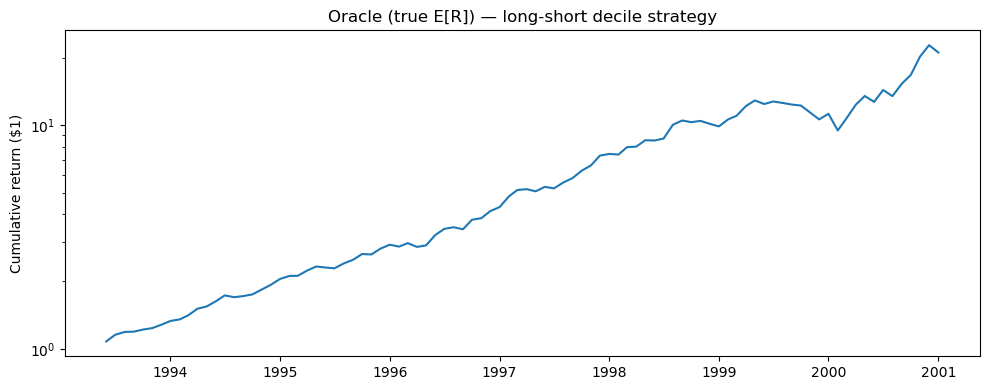


Approximate oracle SR: 2.12


In [4]:
# ── Helper functions (used throughout the notebook) ──────────

def long_short_decile(group, signal_col='er'):
    """Each month: long top decile, short bottom decile."""
    n = len(group)
    if n < 20:
        return np.nan
    decile = n // 10
    sorted_g = group.sort_values(signal_col)
    return sorted_g['ret'].iloc[-decile:].mean() - sorted_g['ret'].iloc[:decile].mean()

# Running scoreboard — each model adds a row
all_results = []

def evaluate_model(er_hat, name, show_plot=False):
    """Compute L-S strategy from predicted E[R], add to running scoreboard."""
    df = pd.DataFrame({'er_hat': er_hat, 'ret': Y_synth_te}, index=Y_ctrl_te.index)
    ls = df.groupby('date').apply(long_short_decile, signal_col='er_hat').dropna()
    ls.index = pd.to_datetime(ls.index)

    ann_ret = ls.mean() * 12
    ann_vol = ls.std() * np.sqrt(12)
    sr = ann_ret / ann_vol if ann_vol > 0 else 0

    all_results.append({'Model': name, 'Ann. Return': ann_ret,
                        'Ann. Vol': ann_vol, 'Sharpe': sr})

    print(f"{name}:  SR = {sr:.2f}  |  Ann. Return = {ann_ret*100:.1f}%  |  Ann. Vol = {ann_vol*100:.1f}%")

    if show_plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot((1 + ls).cumprod(), linewidth=1.5)
        ax.set_ylabel('Cumulative return ($1)')
        ax.set_title(f'{name} — long-short decile strategy')
        ax.set_yscale('log')
        plt.tight_layout()
        plt.show()

    return ls

def plot_coefficients(coef_est, title='Estimated vs. true coefficients'):
    """Bar chart comparing estimated coefficients to true lambda."""
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(chars))
    width = 0.35
    ax.bar(x - width/2, lam, width, label='True \u03bb', alpha=0.7)
    ax.bar(x + width/2, coef_est / (alpha if alpha != 0 else 1), width,
           label='Estimated (scaled)', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(chars, rotation=90, fontsize=7)
    ax.legend()
    ax.set_title(title)
    ax.axhline(0, color='gray', lw=0.5)
    plt.tight_layout()
    plt.show()

def show_scoreboard():
    """Display the running comparison table."""
    df = pd.DataFrame(all_results)
    return (df.style
        .format({'Ann. Return': '{:.1%}', 'Ann. Vol': '{:.1%}', 'Sharpe': '{:.2f}'})
        .set_properties(subset=['Model'], **{'text-align': 'left', 'font-weight': 'bold', 'width': '250px'})
        .set_properties(subset=['Ann. Return', 'Ann. Vol', 'Sharpe'], **{'text-align': 'right'})
        .hide(axis='index')
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 12px')]},
            {'selector': 'td', 'props': [('padding', '4px 12px')]},
        ])
    )

# ── Oracle performance ───────────────────────────────────────
ls_oracle = evaluate_model(er_te, 'Oracle (true E[R])', show_plot=True)
print(f"\nApproximate oracle SR: {oracle_sr:.2f}")

## Linear Models with Regularization

OLS with 30+ features and a low signal-to-noise ratio overfits badly. Most estimated coefficients end up fitting noise rather than genuine predictive relationships.

**Regularization** adds a penalty term to the objective that shrinks coefficients toward zero. This introduces bias (the estimates are no longer unbiased) but dramatically reduces variance — the key tradeoff.

Two main flavors:

| Penalty | Name | Effect |
|---------|------|--------|
| $\|\beta\|_1 = \sum \|\beta_j\|$ | **L1 (Lasso)** | Drives some coefficients exactly to zero → automatic feature selection |
| $\|\beta\|_2^2 = \sum \beta_j^2$ | **L2 (Ridge)** | Shrinks all coefficients proportionally → handles correlated features |

In finance, Lasso is a natural starting point because we believe most of the hundreds of proposed characteristics are noise. We want the model to systematically identify the handful that genuinely predict returns, while setting the rest to zero.

### Lasso Regression (L1 Regularization)

The Lasso solves:

$$\min_{\beta} \; \frac{1}{2n} \sum_{i=1}^n \left( y_i - X_i'\beta \right)^2 + \alpha \|\beta\|_1$$

The penalty parameter $\alpha$ controls sparsity:
- Large $\alpha$ → more coefficients driven to zero → simpler, more biased model
- Small $\alpha$ → fewer zeros → closer to OLS, more variance

The key property of Lasso is **automatic feature selection**: irrelevant coefficients are driven to exactly zero, not just shrunk close to zero. In our context, this means: which of the ~30 firm characteristics actually matter for predicting next month's stock return?

**Weakness:** Among correlated features (e.g., several value measures like book-to-market, earnings-to-price, cash-flow-to-price), Lasso tends to arbitrarily pick one and zero out the others. This can be unstable — small changes in the data can swap which variable survives.

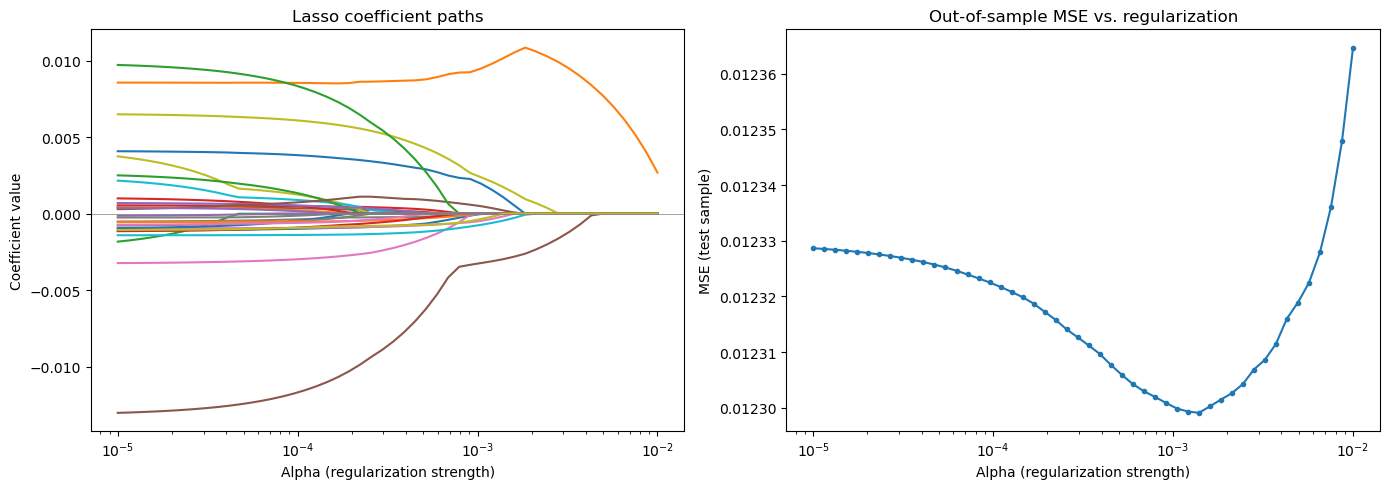

Best alpha: 0.001389
Best test MSE: 0.012299


In [5]:
# Lasso regularization path
# Training on synthetic returns — the signal is alpha * lambda' X
alphas_lasso = np.logspace(-5, -2, 50)
coef_paths = []
mses = []

for a in alphas_lasso:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_tr_std, Y_synth_tr)
    coef_paths.append(model.coef_)
    mses.append(mean_squared_error(Y_synth_te, model.predict(X_te_std)))

coef_paths = np.array(coef_paths)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for i in range(coef_paths.shape[1]):
    ax.plot(alphas_lasso, coef_paths[:, i])
ax.set_xscale('log')
ax.set_xlabel('Alpha (regularization strength)')
ax.set_ylabel('Coefficient value')
ax.set_title('Lasso coefficient paths')
ax.axhline(0, color='gray', linewidth=0.5)

ax = axes[1]
ax.plot(alphas_lasso, mses, 'o-', markersize=3)
ax.set_xscale('log')
ax.set_xlabel('Alpha (regularization strength)')
ax.set_ylabel('MSE (test sample)')
ax.set_title('Out-of-sample MSE vs. regularization')
plt.tight_layout()
plt.show()

best_alpha = alphas_lasso[np.argmin(mses)]
print(f"Best alpha: {best_alpha:.6f}")
print(f"Best test MSE: {min(mses):.6f}")

Surviving features: 8 out of 29
Test R²: 0.0089

Non-zero coefficients:
indrrev   -0.002970
momrev    -0.000450
nissa     -0.000178
shvol     -0.000003
sp         0.000217
valuem     0.001079
mom12      0.001740
value      0.010156


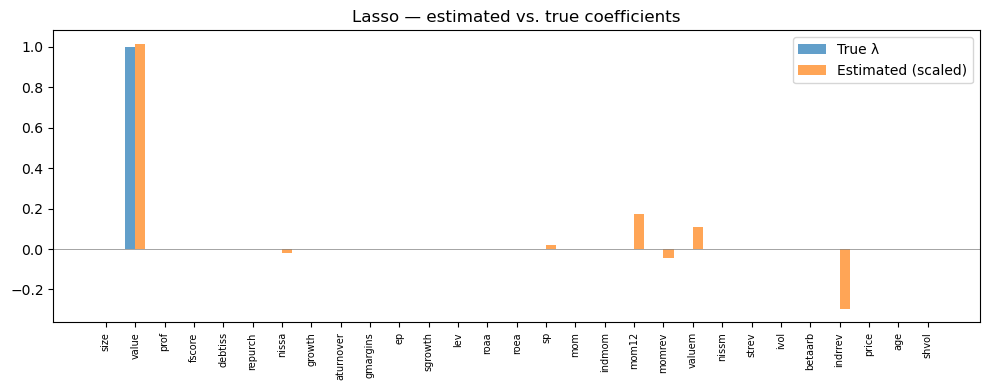

Lasso (linear):  SR = 2.39  |  Ann. Return = 46.7%  |  Ann. Vol = 19.5%


Model,Ann. Return,Ann. Vol,Sharpe
Oracle (true E[R]),42.4%,19.9%,2.13
Lasso (linear),46.7%,19.5%,2.39


In [6]:
# Fit at best alpha and compare to truth
lasso_best = Lasso(alpha=best_alpha, max_iter=10000)
lasso_best.fit(X_tr_std, Y_synth_tr)

surviving = pd.Series(lasso_best.coef_, index=chars)
surviving = surviving[surviving != 0].sort_values()
print(f"Surviving features: {len(surviving)} out of {len(chars)}")
print(f"Test R²: {r2_score(Y_synth_te, lasso_best.predict(X_te_std)):.4f}")
print(f"\nNon-zero coefficients:")
print(surviving.to_string())

# How close are estimated coefficients to truth?
plot_coefficients(lasso_best.coef_, 'Lasso — estimated vs. true coefficients')

# Long-short performance
er_hat_lasso = lasso_best.predict(X_te_std)
ls_lasso = evaluate_model(er_hat_lasso, 'Lasso (linear)')
show_scoreboard()

The Lasso recovers some of the true signal direction, but with noise in the coefficient estimates.

The surviving features tell us which characteristics the Lasso selects, and we can compare them directly to the true $\lambda$ vector.

> **💡 Key Insight:** The Lasso is doing exactly what a financial economist does when selecting factors — deciding which characteristics actually predict returns and which are noise. The difference is that Lasso does it systematically across all characteristics simultaneously.

### Adding Interactions

One reason a linear model might miss signal: the relationship between a characteristic and returns may depend on *another* characteristic.

**Example:** Momentum might predict returns more strongly for small stocks than for large stocks. A linear model with separate momentum and size terms cannot capture this — but a model with a momentum $\times$ size interaction term can:

$$R_{i,t+1} = \sum_j b_j x_{ij,t} + \sum_{l < j} c_{lj} \, x_{il,t} \, x_{ij,t} + \varepsilon_{i,t+1}$$

Adding all pairwise interactions blows up the dimensionality: from 30 features to roughly 500. This makes regularization even more critical — without it, the model will fit noise in hundreds of interaction coefficients.

> **⚠️ Caution:** When creating polynomial/interaction features, use `poly.fit_transform()` on training data and `poly.transform()` (not `fit_transform()`) on tuning data. Fitting on tuning data leaks information about the tuning distribution into the feature construction.

In [7]:
# Add pairwise interaction features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_int = poly.fit_transform(X_tr_std)
X_test_int = poly.transform(X_te_std)

print(f"Features: {X_tr_std.shape[1]} → {X_train_int.shape[1]} (with interactions)")

# Lasso with interactions
alphas_int = [0.0005, 0.00075, 0.001, 0.0015, 0.002, 0.00225]
mses_int = []
for a in alphas_int:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_train_int, Y_synth_tr)
    mses_int.append(mean_squared_error(Y_synth_te, model.predict(X_test_int)))

best_int = Lasso(alpha=alphas_int[np.argmin(mses_int)], max_iter=10000)
best_int.fit(X_train_int, Y_synth_tr)

er_hat_int = best_int.predict(X_test_int)
ls_int = evaluate_model(er_hat_int, 'Lasso (interactions)')

print(f"\nBest interaction MSE: {min(mses_int):.6f}")
print(f"Best linear-only MSE: {min(mses):.6f}")
show_scoreboard()

Features: 29 → 435 (with interactions)
Lasso (interactions):  SR = 2.40  |  Ann. Return = 46.8%  |  Ann. Vol = 19.5%

Best interaction MSE: 0.012298
Best linear-only MSE: 0.012299


Model,Ann. Return,Ann. Vol,Sharpe
Oracle (true E[R]),42.4%,19.9%,2.13
Lasso (linear),46.7%,19.5%,2.39
Lasso (interactions),46.8%,19.5%,2.40


Adding interactions provides virtually no improvement out of sample. This is a common finding — with a low signal-to-noise ratio, the extra flexibility mostly fits noise rather than capturing genuine interaction effects. The curse of dimensionality bites hard.

### Elastic Net (L1 + L2 Regularization)

Elastic Net combines the L1 (Lasso) and L2 (Ridge) penalties:

$$\min_{\beta} \; \frac{1}{2n}\sum_{i=1}^n (y_i - X_i'\beta)^2 + \alpha_1 \|\beta\|_1 + \alpha_2 \|\beta\|_2^2$$

In scikit-learn, the `l1_ratio` parameter controls the mix:
- `l1_ratio = 1.0` → pure Lasso
- `l1_ratio = 0.0` → pure Ridge
- `l1_ratio = 0.5` → equal weight on both penalties

**When to prefer Elastic Net over Lasso:** When characteristics are highly correlated (e.g., multiple value measures like book-to-market, earnings-to-price, cash-flow-to-price, or multiple momentum measures at different horizons). Lasso arbitrarily picks one from a correlated group and zeros out the rest; Elastic Net tends to keep groups of correlated features together.

In practice, Elastic Net often provides a marginal improvement over Lasso for return prediction, but the difference is typically small.

Elastic Net — Test MSE: 0.012306
Non-zero coefficients: 18 / 29


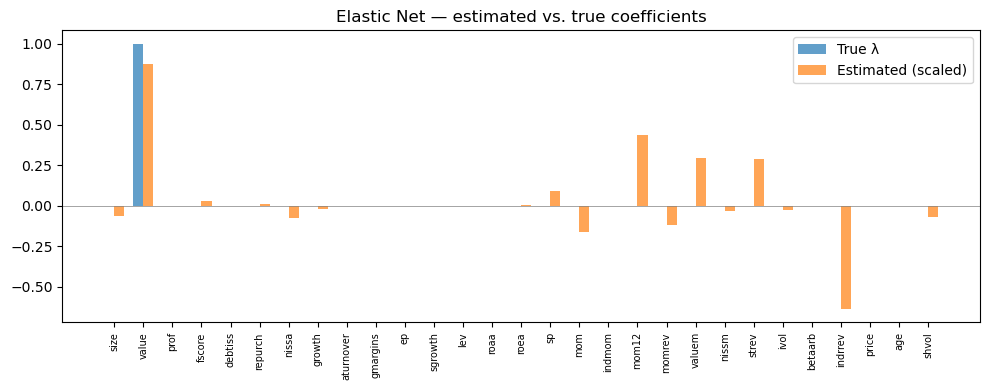

Elastic Net:  SR = 2.25  |  Ann. Return = 46.6%  |  Ann. Vol = 20.7%


Model,Ann. Return,Ann. Vol,Sharpe
Oracle (true E[R]),42.4%,19.9%,2.13
Lasso (linear),46.7%,19.5%,2.39
Lasso (interactions),46.8%,19.5%,2.40
Elastic Net,46.6%,20.7%,2.25
Elastic Net,46.6%,20.7%,2.25


In [9]:
enet = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)
enet.fit(X_tr_std, Y_synth_tr)

mse_enet = mean_squared_error(Y_synth_te, enet.predict(X_te_std))
print(f"Elastic Net — Test MSE: {mse_enet:.6f}")
print(f"Non-zero coefficients: {np.sum(enet.coef_ != 0)} / {len(chars)}")

plot_coefficients(enet.coef_, 'Elastic Net — estimated vs. true coefficients')

er_hat_enet = enet.predict(X_te_std)
ls_enet = evaluate_model(er_hat_enet, 'Elastic Net')
show_scoreboard()

### Non-Parametric Features: Percentile Dummies

What if the relationship between a characteristic and returns is not linear at all?

**Example:** Returns might be flat across most of the size distribution but drop sharply for the smallest 20% of stocks. A linear model would spread that effect across the entire range, diluting it.

A simple non-parametric approach: instead of using the raw characteristic value, replace it with indicator variables for each percentile bin:

$$R_{i,t+1} = \sum_{j=1}^K \sum_{p=1}^P \beta_{j,p} \cdot \mathbf{1}\{x_{ij,t} \in \text{Percentile}_p\}$$

This lets each bin have its own coefficient — maximum flexibility for each individual characteristic. The model can learn that being in the bottom quintile of momentum matters a lot, while the middle quintiles are irrelevant.

The cost: dimensionality explodes. With 30 characteristics and 5 bins each, we have $30 \times 5 = 150$ features. Regularization is essential to prevent overfitting.

In [10]:
# Convert characteristics to percentile dummies
num_percentiles = 5
new_cols_train = []
new_cols_test = []

for col in X_ctrl_tr.columns:
    bins_tr = X_ctrl_tr[col].groupby('date').transform(
        lambda x: pd.qcut(x, q=num_percentiles, labels=False, duplicates='drop'))
    for p in range(num_percentiles):
        new_cols_train.append((bins_tr == p).astype(int).rename(f"{col}_p{p+1}"))

    bins_te = X_ctrl_te[col].groupby('date').transform(
        lambda x: pd.qcut(x, q=num_percentiles, labels=False, duplicates='drop'))
    for p in range(num_percentiles):
        new_cols_test.append((bins_te == p).astype(int).rename(f"{col}_p{p+1}"))

X_train_pct = pd.concat(new_cols_train, axis=1)
X_test_pct = pd.concat(new_cols_test, axis=1)
print(f"Percentile features: {X_train_pct.shape[1]}")

alphas_pct = [0.0005, 0.001, 0.0015, 0.002]
mses_pct = []
for a in alphas_pct:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_train_pct, Y_synth_tr)
    mses_pct.append(mean_squared_error(Y_synth_te, model.predict(X_test_pct)))

best_pct = Lasso(alpha=alphas_pct[np.argmin(mses_pct)], max_iter=10000)
best_pct.fit(X_train_pct, Y_synth_tr)

er_hat_pct = best_pct.predict(X_test_pct)
ls_pct = evaluate_model(er_hat_pct, 'Lasso (percentile)')
show_scoreboard()

Percentile features: 145
Lasso (percentile):  SR = 1.52  |  Ann. Return = 37.3%  |  Ann. Vol = 24.6%


Model,Ann. Return,Ann. Vol,Sharpe
Oracle (true E[R]),42.4%,19.9%,2.13
Lasso (linear),46.7%,19.5%,2.39
Lasso (interactions),46.8%,19.5%,2.40
Elastic Net,46.6%,20.7%,2.25
Elastic Net,46.6%,20.7%,2.25
Lasso (percentile),37.3%,24.6%,1.52


## Tree-Based Methods

Trees take a fundamentally different approach to function approximation. Instead of fitting a single global function $F(X)$, they **recursively partition the feature space** into regions and fit a constant prediction in each region.

A single decision tree asks a sequence of yes/no questions: *Is momentum > 0.5? If yes, is size < median? If yes, predict return = 0.8%.* Each terminal node (leaf) gives a predicted return for all stocks that land in that partition.

**Key advantages for finance:**
1. **Automatic interaction discovery** — a tree that first splits on size and then on momentum within the small-stock branch has implicitly learned a size-momentum interaction, without anyone specifying it.
2. **Non-linear by construction** — trees use thresholds, not slopes. They can capture step functions, kinks, and saturation effects naturally.
3. **Feature importance** is a natural byproduct of which variables the tree chooses to split on.

**Key disadvantage:** A single deep tree overfits catastrophically, especially with noisy data. The solution is to combine many trees.

Two main strategies:
- **Bagging (Random Forest):** Grow many trees on bootstrap samples of the data and average their predictions. Each tree also considers only a random subset of features at each split, decorrelating the trees. This reduces variance.
- **Boosting (GBRT):** Grow trees sequentially, with each new tree fitting the residuals (errors) of the ensemble so far. This reduces bias.

![Regression Tree](https://github.com/amoreira2/Fin418/blob/main/assets/plots/regressionTree.jpg?raw=1)

### Random Forest

A Random Forest averages the predictions of many independent trees:

$$\hat{y} = \frac{1}{T}\sum_{t=1}^T h_t(X)$$

where each $h_t$ is a regression tree trained on a different bootstrap sample of the training data. At each split, only a random subset of features is considered — this decorrelates the trees and prevents a single dominant feature from appearing in every tree.

**Key hyperparameters:**
- `n_estimators`: Number of trees. More is generally better (reduces variance), but with diminishing returns.
- `max_depth`: Maximum depth of each tree. Controls complexity — deeper trees capture more interactions but overfit more.
- `min_samples_leaf`: Minimum observations in a leaf node. Larger values act as regularization.

For financial data with low signal-to-noise, **shallow trees** (`max_depth` = 3–5) almost always work best. Deep trees fit noise in the training sample and fail out of sample.

Random Forest — Test MSE: 0.012329


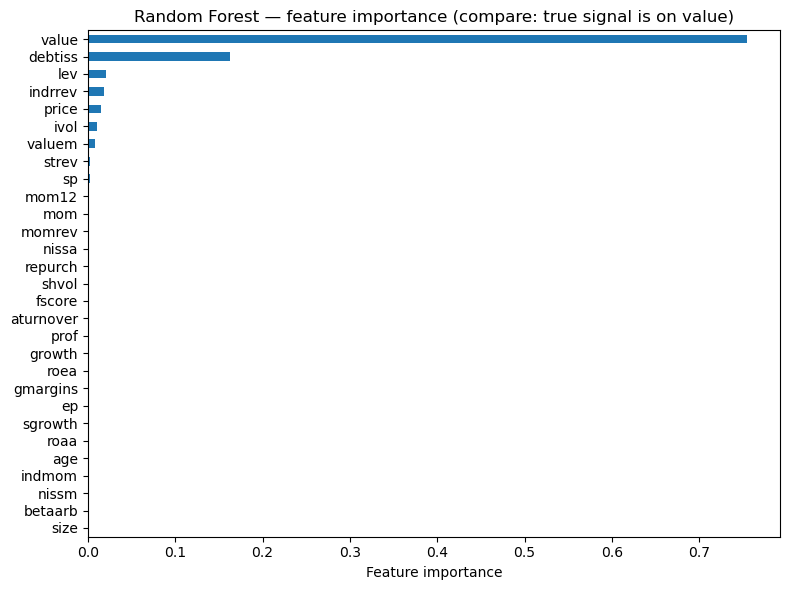

Random Forest:  SR = 1.98  |  Ann. Return = 44.0%  |  Ann. Vol = 22.2%


Model,Ann. Return,Ann. Vol,Sharpe
Oracle (true E[R]),42.4%,19.9%,2.13
Lasso (linear),46.7%,19.5%,2.39
Lasso (interactions),46.8%,19.5%,2.40
Elastic Net,46.6%,20.7%,2.25
Elastic Net,46.6%,20.7%,2.25
Lasso (percentile),37.3%,24.6%,1.52
Random Forest,44.0%,22.2%,1.98


In [11]:
rf = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42, n_jobs=-1)
rf.fit(X_tr_std, Y_synth_tr)

mse_rf = mean_squared_error(Y_synth_te, rf.predict(X_te_std))
print(f"Random Forest — Test MSE: {mse_rf:.6f}")

# Feature importance vs truth
importance = pd.Series(rf.feature_importances_, index=chars).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax)
ax.set_xlabel('Feature importance')
ax.set_title('Random Forest — feature importance (compare: true signal is on value)')
plt.tight_layout()
plt.show()

er_hat_rf = rf.predict(X_te_std)
ls_rf = evaluate_model(er_hat_rf, 'Random Forest')
show_scoreboard()

### Gradient Boosted Regression Trees

Instead of averaging independent trees, GBRT builds trees sequentially. Each new tree fits the **residuals** of the current ensemble:

$$\hat{y}_t(X) = \hat{y}_{t-1}(X) + \nu \cdot g_t(X)$$

where $g_t$ is a shallow tree fitted to the residuals of iteration $t-1$, and $\nu$ is the **learning rate** — a shrinkage factor that controls how much each tree contributes.

- Small $\nu$ with many trees often works best (the ensemble learns slowly but carefully)
- GBRT is generally the strongest off-the-shelf method for tabular data — this is the approach behind the "XGBoost revolution" that dominates Kaggle competitions
- But it requires more careful tuning than Random Forest: learning rate, number of trees, max depth, subsampling rate — more knobs to turn means more opportunities to overfit the tuning process itself

GBRT — Test MSE: 0.012620


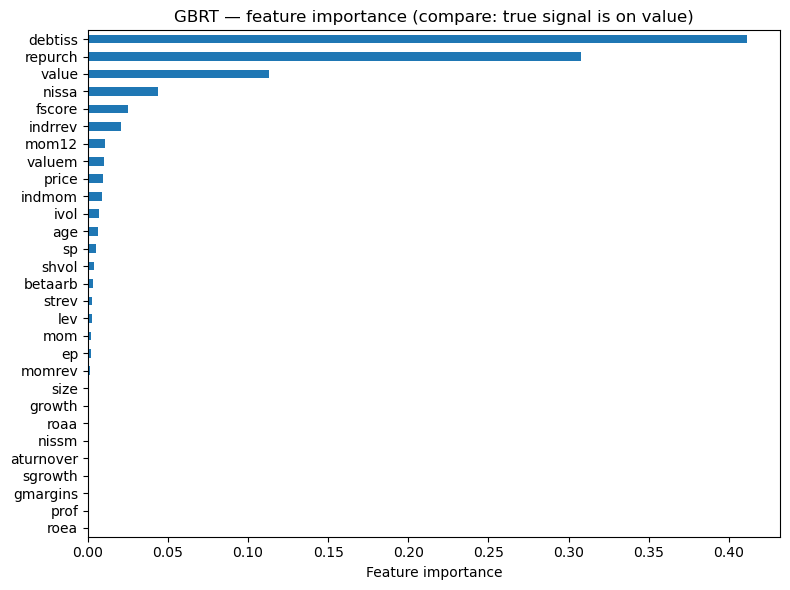

GBRT:  SR = 1.91  |  Ann. Return = 31.6%  |  Ann. Vol = 16.6%


Model,Ann. Return,Ann. Vol,Sharpe
Oracle (true E[R]),42.4%,19.9%,2.13
Lasso (linear),46.7%,19.5%,2.39
Lasso (interactions),46.8%,19.5%,2.40
Elastic Net,46.6%,20.7%,2.25
Elastic Net,46.6%,20.7%,2.25
Lasso (percentile),37.3%,24.6%,1.52
Random Forest,44.0%,22.2%,1.98
GBRT,31.6%,16.6%,1.91


In [12]:
gbrt = GradientBoostingRegressor(n_estimators=50, learning_rate=0.2, max_depth=3, random_state=42)
gbrt.fit(X_tr_std, Y_synth_tr)

mse_gbrt = mean_squared_error(Y_synth_te, gbrt.predict(X_te_std))
print(f"GBRT — Test MSE: {mse_gbrt:.6f}")

# Feature importance vs truth
importance_gb = pd.Series(gbrt.feature_importances_, index=chars).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
importance_gb.plot(kind='barh', ax=ax)
ax.set_xlabel('Feature importance')
ax.set_title('GBRT — feature importance (compare: true signal is on value)')
plt.tight_layout()
plt.show()

er_hat_gbrt = gbrt.predict(X_te_std)
ls_gbrt = evaluate_model(er_hat_gbrt, 'GBRT')
show_scoreboard()

## Neural Networks

A neural network is a flexible function approximator built from layers of simple transformations:

$$\hat{y} = f\left(W^{[L]} \, \sigma\left(W^{[L-1]} \cdots \sigma\left(W^{[1]}X + b^{[1]}\right) \cdots + b^{[L-1]}\right) + b^{[L]}\right)$$

**Activation functions** ($\sigma$, typically ReLU $= \max(0,x)$) introduce non-linearity between layers. Without them, stacking linear layers would just give another linear model.

The **universal approximation theorem** guarantees that a sufficiently wide single-hidden-layer network can approximate *any* continuous function to arbitrary precision. In principle, a neural network can learn any $F(X)$ — all the interactions, non-linearities, threshold effects, and complex patterns.

**For finance, NNs present a fundamental tension:**
- On one hand, they can capture arbitrarily complex relationships between characteristics and returns.
- On the other hand, they are massively overparameterized. A modest network with 3 hidden layers of 64 neurons has roughly 8,000 parameters. With monthly returns that are 99.5% noise, this is a recipe for overfitting.

**Regularization is not optional — it is essential:**
1. **L1/L2 weight penalties** — shrink weights toward zero, just like Ridge/Lasso for linear models
2. **Dropout** — randomly set a fraction of neurons to zero during training, forcing the network to build redundant representations
3. **Early stopping** — monitor performance on the tuning set and stop training when it starts deteriorating

![Neural Networks](https://github.com/amoreira2/Fin418/blob/main/assets/plots/neural_networks.jpg?raw=1)

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = 'cpu'
print(f"PyTorch {torch.__version__}")

PyTorch 2.11.0


In [14]:
class ReturnPredictor(nn.Module):
    def __init__(self, input_dim, neurons=64, num_layers=3, dropout=0.0):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_dim, neurons))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(neurons, neurons))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(neurons, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_nn(model, X_tr, Y_tr, X_val, Y_val, epochs=10, batch_size=256,
             lr=1e-3, weight_decay=0.0, patience=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    
    train_ds = TensorDataset(torch.tensor(X_tr.values, dtype=torch.float32),
                             torch.tensor(Y_tr.values, dtype=torch.float32).unsqueeze(1))
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    
    X_val_t = torch.tensor(X_val.values, dtype=torch.float32)
    Y_val_t = torch.tensor(Y_val.values, dtype=torch.float32).unsqueeze(1)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), Y_val_t).item()
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} -- train MSE: {epoch_loss/len(train_ds):.6f}, val MSE: {val_loss:.6f}")
        
        if patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    model.load_state_dict(best_state)
                    break
    return model


def predict_nn(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X.values, dtype=torch.float32)).numpy().flatten()


In [15]:
# Create DataFrame versions for PyTorch (train_nn expects .values attribute)
X_tr_df = pd.DataFrame(X_tr_std, columns=chars, index=Y_ctrl_tr.index)
X_te_df = pd.DataFrame(X_te_std, columns=chars, index=Y_ctrl_te.index)
Y_tr_series = pd.Series(Y_synth_tr, index=Y_ctrl_tr.index)
Y_te_series = pd.Series(Y_synth_te, index=Y_ctrl_te.index)

In [16]:
# Basic NN -- no regularization, trained on synthetic returns
print("Training basic NN (no regularization)...")
nn_basic = ReturnPredictor(len(chars), neurons=64, num_layers=3)
nn_basic = train_nn(nn_basic, X_tr_df, Y_tr_series, X_te_df, Y_te_series,
                    epochs=20, batch_size=256)

mse_nn_basic = mean_squared_error(Y_synth_te, predict_nn(nn_basic, X_te_df))
print(f"\nBasic NN -- Test MSE: {mse_nn_basic:.6f}")

er_hat_nn_basic = predict_nn(nn_basic, X_te_df)
ls_nn_basic = evaluate_model(er_hat_nn_basic, 'Neural Net (basic)')
show_scoreboard()

Training basic NN (no regularization)...
  Epoch   1/20 -- train MSE: 0.009393, val MSE: 0.012324
  Epoch   5/20 -- train MSE: 0.009198, val MSE: 0.012411
  Epoch  10/20 -- train MSE: 0.009103, val MSE: 0.012517
  Epoch  15/20 -- train MSE: 0.008996, val MSE: 0.012614
  Epoch  20/20 -- train MSE: 0.008895, val MSE: 0.012712

Basic NN -- Test MSE: 0.012712
Neural Net (basic):  SR = 1.53  |  Ann. Return = 28.0%  |  Ann. Vol = 18.3%


Model,Ann. Return,Ann. Vol,Sharpe
Oracle (true E[R]),42.4%,19.9%,2.13
Lasso (linear),46.7%,19.5%,2.39
Lasso (interactions),46.8%,19.5%,2.40
Elastic Net,46.6%,20.7%,2.25
Elastic Net,46.6%,20.7%,2.25
Lasso (percentile),37.3%,24.6%,1.52
Random Forest,44.0%,22.2%,1.98
GBRT,31.6%,16.6%,1.91
Neural Net (basic),28.0%,18.3%,1.53


### Regularizing Neural Networks

Without regularization, neural networks will memorize training data noise. The key tools:

1. **L2 weight decay**: shrinks all weights, prevents any single neuron from dominating. In PyTorch, this is the `weight_decay` parameter in the optimizer.
2. **Dropout**: randomly zeros out neurons during training — forces redundancy, acts like an ensemble of smaller networks.
3. **Early stopping**: monitor validation loss and stop when it starts increasing — prevents overtraining.

> **📌 Remember:**
>
> A good starting recipe: weight decay = 1e-4, dropout = 0.1–0.3, early stopping with patience = 5–10 epochs.

In [17]:
# Regularized NN -- weight decay, dropout, early stopping
print("Training regularized NN...")
nn_reg = ReturnPredictor(len(chars), neurons=64, num_layers=3, dropout=0.1)
nn_reg = train_nn(nn_reg, X_tr_df, Y_tr_series, X_te_df, Y_te_series,
                  epochs=50, batch_size=256, weight_decay=1e-5, patience=10)

mse_nn_reg = mean_squared_error(Y_synth_te, predict_nn(nn_reg, X_te_df))
print(f"\nRegularized NN -- Test MSE: {mse_nn_reg:.6f}")
print(f"Basic NN -- Test MSE:       {mse_nn_basic:.6f}")

er_hat_nn_reg = predict_nn(nn_reg, X_te_df)
ls_nn_reg = evaluate_model(er_hat_nn_reg, 'Neural Net (regularized)')
show_scoreboard()

Training regularized NN...
  Epoch   1/50 -- train MSE: 0.009426, val MSE: 0.012327
  Epoch   5/50 -- train MSE: 0.009271, val MSE: 0.012324
  Epoch  10/50 -- train MSE: 0.009253, val MSE: 0.012365
  Early stopping at epoch 12

Regularized NN -- Test MSE: 0.012322
Basic NN -- Test MSE:       0.012712
Neural Net (regularized):  SR = 2.61  |  Ann. Return = 45.9%  |  Ann. Vol = 17.6%


Model,Ann. Return,Ann. Vol,Sharpe
Oracle (true E[R]),42.4%,19.9%,2.13
Lasso (linear),46.7%,19.5%,2.39
Lasso (interactions),46.8%,19.5%,2.40
Elastic Net,46.6%,20.7%,2.25
Elastic Net,46.6%,20.7%,2.25
Lasso (percentile),37.3%,24.6%,1.52
Random Forest,44.0%,22.2%,1.98
GBRT,31.6%,16.6%,1.91
Neural Net (basic),28.0%,18.3%,1.53
Neural Net (regularized),45.9%,17.6%,2.61


Let's visualize what the neural network has learned by comparing its predicted returns to the true expected returns:

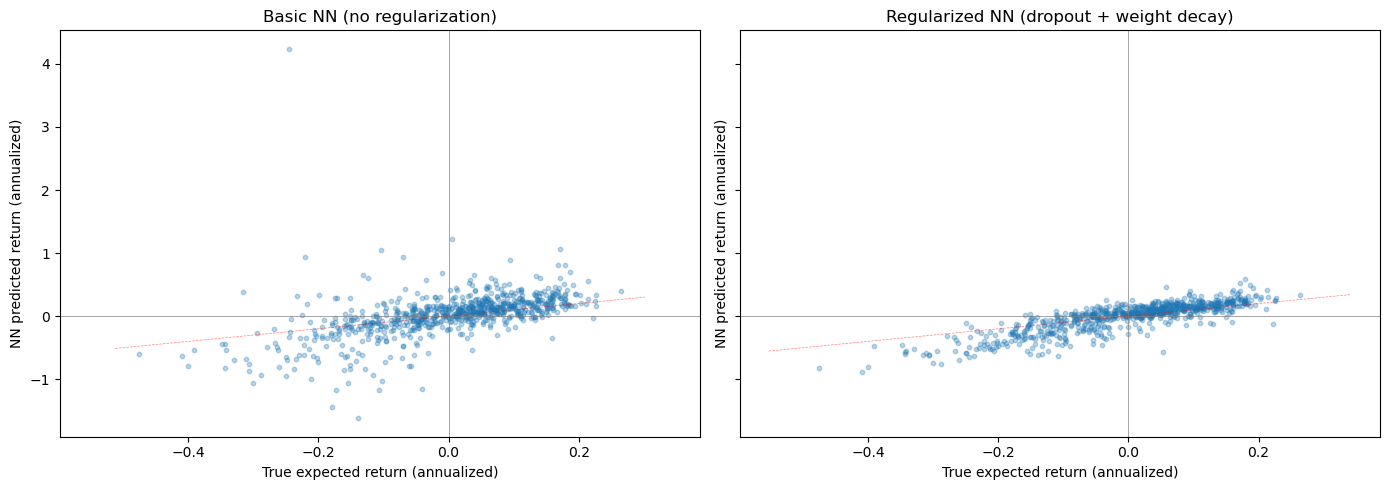

In [18]:
# Compare NN predictions to true expected returns (we know the truth!)
last_date = X_te_df.index.get_level_values(0).unique().max()
X_last = X_te_df.loc[last_date]

pred_basic = pd.Series(predict_nn(nn_basic, X_last), index=X_last.index, name='Basic NN')
pred_reg = pd.Series(predict_nn(nn_reg, X_last), index=X_last.index, name='Regularized NN')
true_er = pd.Series(alpha * (((X_last - mu_x) / sd_x).values @ lam),
                     index=X_last.index, name='True E[R]')
combined = pd.concat([pred_basic, pred_reg, true_er], axis=1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, col, title in zip(axes, ['Basic NN', 'Regularized NN'],
                           ['Basic NN (no regularization)', 'Regularized NN (dropout + weight decay)']):
    ax.scatter(combined['True E[R]'] * 12, combined[col] * 12, alpha=0.3, s=10)
    ax.set_xlabel('True expected return (annualized)')
    ax.set_ylabel('NN predicted return (annualized)')
    ax.set_title(title)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    # 45-degree line
    lims = ax.get_xlim()
    ax.plot(lims, lims, 'r--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

## Model Comparison

Now let's put all models side by side and ask the key question: **does added complexity buy us anything for return prediction?**

In many domains — image recognition, natural language processing, speech — deeper and more flexible models dramatically outperform simpler ones. The gap between a linear classifier and a deep neural network on ImageNet is enormous.

In finance, the answer is often: **barely.** The reason is the signal-to-noise ratio. When 99.5% of the variation in returns is unpredictable noise, a model that is 1% better at capturing the signal but 2% worse at ignoring noise will *underperform* a simpler model. The marginal benefit of flexibility is overwhelmed by the marginal cost of overfitting.

In [19]:
# Final scoreboard
print(f"Oracle SR (analytical approximation): {oracle_sr:.2f}\n")
show_scoreboard()

Oracle SR (analytical approximation): 2.12



Model,Ann. Return,Ann. Vol,Sharpe
Oracle (true E[R]),42.4%,19.9%,2.13
Lasso (linear),46.7%,19.5%,2.39
Lasso (interactions),46.8%,19.5%,2.40
Elastic Net,46.6%,20.7%,2.25
Elastic Net,46.6%,20.7%,2.25
Lasso (percentile),37.3%,24.6%,1.52
Random Forest,44.0%,22.2%,1.98
GBRT,31.6%,16.6%,1.91
Neural Net (basic),28.0%,18.3%,1.53
Neural Net (regularized),45.9%,17.6%,2.61


### Discussion

Several patterns emerge from the comparison:

- **Simpler regularized linear models are competitive** with or better than complex non-linear models. The Lasso, despite being the simplest method in our comparison, is hard to beat.
- **Adding interactions and non-parametric features** does not reliably improve out-of-sample performance. The extra flexibility mostly captures noise.
- **Tree-based methods** can sometimes improve on linear models, but the gains are modest and depend heavily on hyperparameter choices.
- **Neural networks** require careful regularization to avoid being the worst performer. With proper dropout, weight decay, and early stopping they become competitive, but rarely dominate.

These findings are consistent with Gu, Kelly & Xiu (2020, *Review of Financial Studies*), "Empirical Asset Pricing via Machine Learning." They find that tree-based methods and neural networks can improve on linear models for return prediction, but the gains are modest and require careful regularization and tuning. The improvements matter most when applied to very large cross-sections over long time periods.

The key practical lesson: **start simple, validate ruthlessly, and add complexity only if the data demands it.**

> **💡 Key Insight:** The most common mistake in financial ML is not choosing the wrong model — it's evaluating it wrong. Proper time-series cross-validation and genuine out-of-sample testing matter more than model architecture.

### More data, smaller signals

How much training data do we need to detect the signal? Let's vary the number of training months and measure the estimated strategy's Sharpe ratio. We use Ridge regression on the raw characteristics (fast, works at any sample size) to isolate the effect of sample size from the choice of model complexity.


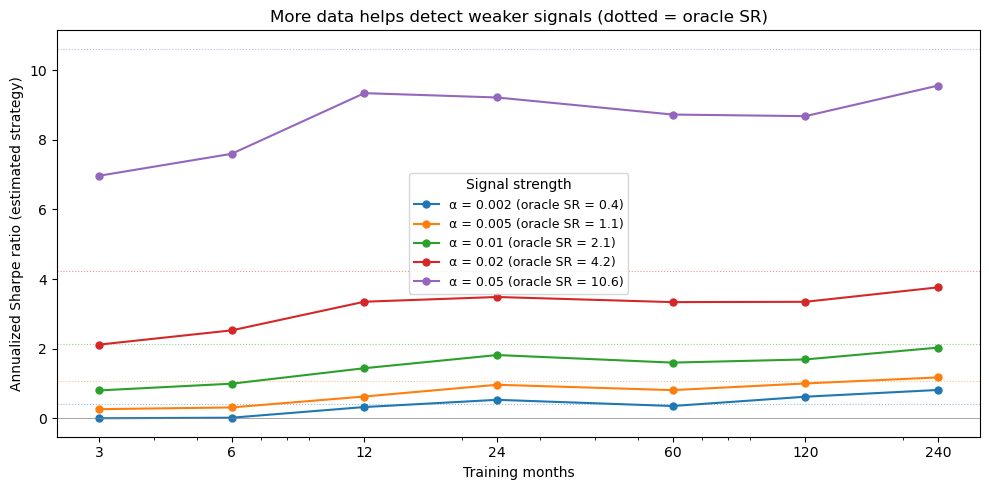

In [20]:
# ── Sharpe ratio vs. training sample size ────────────────────
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

month_grid = [3, 6, 12, 24, 60, 120, len(train_dates)]
alpha_grid = [0.002, 0.005, 0.01, 0.02, 0.05]

sharpe_results = {}
oracle_srs = {}

for a in alpha_grid:
    # Oracle SR for this alpha (analytical approximation)
    cs_std_a = a * np.std(X_tr_std @ lam)
    expected_ls_a = 2 * cs_std_a * phi_z90 / 0.1
    oracle_srs[a] = (expected_ls_a / ls_noise_vol) * np.sqrt(12)
    
    sharpes = []
    for n_m in month_grid:
        np.random.seed(0)
        sel_dates = np.random.choice(train_dates, min(n_m, len(train_dates)), replace=False)
        mask = Y_ctrl_tr.index.get_level_values(0).isin(sel_dates)
        
        Xtr = X_tr_std[mask]
        Ytr = a * (X_tr_std @ lam)[mask] + noise_tr[mask]
        Yte_synth = a * (X_te_std @ lam) + noise_te
        
        ridge = Ridge(alpha=1.0)
        ridge.fit(Xtr, Ytr)
        er_hat = ridge.predict(X_te_std)
        
        df_tmp = pd.DataFrame({'er_hat': er_hat, 'ret': Yte_synth}, index=Y_ctrl_te.index)
        ls_tmp = df_tmp.groupby('date').apply(long_short_decile, signal_col='er_hat').dropna()
        sr = ls_tmp.mean() * 12 / (ls_tmp.std() * np.sqrt(12)) if ls_tmp.std() > 0 else 0
        sharpes.append(sr)
    sharpe_results[a] = sharpes

warnings.filterwarnings('default')

fig, ax = plt.subplots(figsize=(10, 5))
for a in alpha_grid:
    line, = ax.plot(month_grid, sharpe_results[a], 'o-', linewidth=1.5, markersize=5,
                    label=f'\u03b1 = {a} (oracle SR = {oracle_srs[a]:.1f})')
    ax.axhline(oracle_srs[a], color=line.get_color(), ls=':', lw=0.8, alpha=0.5)

ax.set_xlabel('Training months')
ax.set_ylabel('Annualized Sharpe ratio (estimated strategy)')
ax.set_title('More data helps detect weaker signals (dotted = oracle SR)')
ax.set_xscale('log')
ax.set_xticks(month_grid)
ax.set_xticklabels([f'{m}' for m in month_grid])
ax.legend(title='Signal strength', fontsize=9)
ax.axhline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.show()


## Double Descent: When More Parameters Help

Classical statistics teaches a U-shaped bias-variance tradeoff: too simple → underfitting, too complex → overfitting.

**Double descent** challenges this. When you push model complexity *past* the interpolation threshold — where the model has just enough parameters to perfectly fit the training data — test error peaks. But keep going further into the overparameterized regime, and test error *decreases again*. The minimum-norm interpolating solution becomes smoother as you add more parameters.

This helps explain why massively overparameterized neural networks generalize well in domains like computer vision and NLP.

**Does it work for financial returns?** Let's find out using our actual data. We take a subsample of 300 training observations and fit them using random ReLU features of increasing dimension $p$. These are the same features a single-hidden-layer neural network would learn:
$$\phi_j(x) = \max(0, \; x'w_j + b_j)$$
As $p$ passes $n=300$, we enter the interpolation regime.


In [ ]:
# Double descent with our actual return data
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Subsample training data so we can reach the interpolation threshold
n_sub = 300
idx_sub = np.random.choice(len(X_train), n_sub, replace=False)
X_sub = X_train.iloc[idx_sub].values
Y_sub = Y_train.iloc[idx_sub].values
X_te_dd = X_tuning.values
Y_te_dd = Y_tuning.values

# Standardize
mu_dd, sd_dd = X_sub.mean(0), X_sub.std(0)
sd_dd[sd_dd == 0] = 1
X_sub_s = (X_sub - mu_dd) / sd_dd
X_te_s = (X_te_dd - mu_dd) / sd_dd

# Random ReLU features: phi_j(x) = max(0, x @ w_j + b_j)
d = X_sub_s.shape[1]
max_p = 900
W_dd = np.random.randn(d, max_p) / np.sqrt(d)
b_dd = np.random.randn(max_p) * 0.5

p_values = list(range(5, max_p + 1, 5))
train_mse_dd, test_mse_dd = [], []
ridge_lam = 1e-8

for p in p_values:
    Phi_tr = np.maximum(0, X_sub_s @ W_dd[:, :p] + b_dd[:p])
    Phi_te = np.maximum(0, X_te_s @ W_dd[:, :p] + b_dd[:p])
    if p <= n_sub:
        coef = np.linalg.solve(Phi_tr.T @ Phi_tr + ridge_lam * np.eye(p), Phi_tr.T @ Y_sub)
    else:
        dual_alpha = np.linalg.solve(Phi_tr @ Phi_tr.T + ridge_lam * np.eye(n_sub), Y_sub)
        coef = Phi_tr.T @ dual_alpha
    train_mse_dd.append(np.mean((Y_sub - Phi_tr @ coef)**2))
    test_mse_dd.append(np.mean((Y_te_dd - Phi_te @ coef)**2))

warnings.filterwarnings('default')

naive_mse = np.mean(Y_te_dd**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: log scale — full picture including the enormous spike
ax = axes[0]
ax.semilogy(p_values, train_mse_dd, label='Train MSE', linewidth=1.5)
ax.semilogy(p_values, test_mse_dd, label='Test MSE', linewidth=1.5)
ax.axvline(n_sub, color='gray', ls='--', lw=1, label=f'p = n = {n_sub}')
ax.axhline(naive_mse, color='red', ls=':', lw=1, label=f'Naive (predict 0): {naive_mse:.4f}')
ax.set_xlabel('Number of random features (p)')
ax.set_ylabel('MSE (log scale)')
ax.set_title('Double descent — log scale')
ax.legend(fontsize=9)

# Right: linear scale, capped — shows the second descent clearly
ax = axes[1]
ax.plot(p_values, train_mse_dd, label='Train MSE', linewidth=1.5)
ax.plot(p_values, test_mse_dd, label='Test MSE', linewidth=1.5)
ax.axvline(n_sub, color='gray', ls='--', lw=1, label=f'p = n = {n_sub}')
ax.axhline(naive_mse, color='red', ls=':', lw=1, label=f'Naive (predict 0): {naive_mse:.4f}')
ax.set_xlabel('Number of random features (p)')
ax.set_ylabel('MSE')
ax.set_title('Double descent — linear scale (capped)')
ax.set_ylim(0, naive_mse * 8)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Naive MSE (predict zero):     {naive_mse:.6f}")
print(f"Best MSE before threshold:    {min(test_mse_dd[:len([p for p in p_values if p < n_sub])]):.6f}")
print(f"Peak MSE at threshold:        {max(test_mse_dd):.1f}")
print(f"Best MSE after threshold:     {min(test_mse_dd[len([p for p in p_values if p < n_sub]):]):.6f}")


### What's happening?

Three regimes:

1. **Underparameterized** ($p < n$): Classical bias-variance tradeoff. Test MSE initially falls, then rises as overfitting kicks in.
2. **Interpolation threshold** ($p \approx n$): The model has *just* enough parameters to memorize the training data. It does so using wild, high-frequency coefficients → **worst test error** by orders of magnitude.
3. **Overparameterized** ($p \gg n$): Many solutions interpolate the data. The minimum-norm solution (what least squares returns) is the *smoothest* interpolator — test error decreases.

> **📌 The financial punchline:** Double descent is real — it shows up in actual return data. But notice the red line: even the best overparameterized model can't beat the naive forecast of zero. In high signal-to-noise domains (vision, NLP), the second descent drops *below* the classical optimum. In finance, it doesn't. The signal is simply too weak for overparameterization to help.
>
> This is why **regularization** (staying in the underparameterized regime and shrinking) remains the dominant strategy for financial ML.


In [ ]:
# ── Double descent with date-based subsampling ────────────────
import warnings
warnings.filterwarnings('ignore')

# Double descent requires n << max_p to reach the interpolation threshold.
# With ~900 stocks per month and max_p ≈ 3000, we need at most ~3 months.
n_dd_months = 3     # keep small! (1 month ≈ 900 obs → interpolation at p ≈ 900)

np.random.seed(42)
dd_dates = np.random.choice(train_dates, n_dd_months, replace=False)
mask_dd = Y_ctrl_tr.index.get_level_values(0).isin(dd_dates)
X_dd_train = X_tr_std[mask_dd]
n_obs = X_dd_train.shape[0]
print(f"Double descent training: {n_dd_months} month(s), {n_obs} stocks")
print(f"(Interpolation threshold at p = {n_obs})")

# Subsample test for speed
te_idx = np.random.choice(len(X_te_std), min(5000, len(X_te_std)), replace=False)

# Standardize
mu_dd, sd_dd = X_dd_train.mean(0), X_dd_train.std(0)
sd_dd[sd_dd == 0] = 1
Xn_dd = (X_dd_train - mu_dd) / sd_dd

d = len(chars)
max_p = min(n_obs * 3, 3000)
W_rff = np.random.randn(d, max_p) / np.sqrt(d)
b_rff = np.random.randn(max_p) * 0.5
p_values = list(range(10, max_p + 1, 10))

results_dd = {}

for label, a in [('No signal (actual returns)', 0.0), (f'Injected signal (\u03b1={alpha})', alpha)]:
    Y_dd_tr = a * (X_tr_std @ lam)[mask_dd] + noise_tr[mask_dd]
    Y_dd_te = a * (X_te_std @ lam)[te_idx] + noise_te[te_idx]
    X_dd_te = (X_te_std[te_idx] - mu_dd) / sd_dd
    
    train_mse_loop, test_mse_loop = [], []
    for p in p_values:
        Phi_tr = np.maximum(0, Xn_dd @ W_rff[:, :p] + b_rff[:p])
        Phi_te = np.maximum(0, X_dd_te @ W_rff[:, :p] + b_rff[:p])
        if p <= n_obs:
            coef = np.linalg.solve(Phi_tr.T @ Phi_tr + 1e-8 * np.eye(p), Phi_tr.T @ Y_dd_tr)
        else:
            al = np.linalg.solve(Phi_tr @ Phi_tr.T + 1e-8 * np.eye(n_obs), Y_dd_tr)
            coef = Phi_tr.T @ al
        train_mse_loop.append(np.mean((Y_dd_tr - Phi_tr @ coef)**2))
        test_mse_loop.append(np.mean((Y_dd_te - Phi_te @ coef)**2))
    
    naive_mse = np.mean(Y_dd_te**2)
    results_dd[label] = {'train': train_mse_loop, 'test': test_mse_loop, 'naive': naive_mse}
    pre = len([p for p in p_values if p < n_obs])
    print(f"\n{label}:")
    print(f"  Naive MSE:           {naive_mse:.5f}")
    print(f"  Best pre-threshold:  {min(test_mse_loop[:pre]):.5f}")
    print(f"  Best post-threshold: {min(test_mse_loop[pre:]):.5f}")

warnings.filterwarnings('default')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
noise_floor = np.mean(noise_te[te_idx]**2)

for ax, (label, res) in zip(axes, results_dd.items()):
    ax.semilogy(p_values, res['train'], label='Train MSE', linewidth=1.5)
    ax.semilogy(p_values, res['test'], label='Test MSE', linewidth=1.5)
    ax.axvline(n_obs, color='gray', ls='--', lw=1, label=f'p = n = {n_obs}')
    ax.axhline(res['naive'], color='red', ls=':', lw=1.5, label=f'Naive MSE: {res["naive"]:.4f}')
    ax.axhline(noise_floor, color='green', ls=':', lw=1, label=f'Noise floor: {noise_floor:.4f}')
    ax.set_xlabel('Number of random features (p)')
    ax.set_ylabel('MSE (log scale)')
    ax.set_title(label)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(noise_floor * 0.1, None)

plt.tight_layout()
plt.show()


### The signal-to-noise threshold

**Left panel (no signal):** This is essentially the real return prediction problem. Double descent occurs — test MSE spikes at the interpolation threshold ($p = n$) — but the overparameterized model never drops below the naive benchmark. With no signal to recover, adding parameters just fits noise.

**Right panel (injected signal):** Now there IS something to find. The overparameterized regime recovers the signal and pushes test MSE well below naive, heading toward the **noise floor** (the irreducible error). The overparameterized model even beats the classical optimum (the pre-threshold minimum).

**The lesson:** Double descent is not magic — it requires a real signal to recover. The reason overparameterized models (large neural networks) work spectacularly in vision and NLP is that those domains have *strong* signals. In finance, the signal-to-noise ratio determines whether complexity helps or hurts.

> **📌 Try it yourself:** Change `lam` to put weight on different characteristics (e.g., `'mom'`, `'size'`), spread weight across multiple characteristics, or adjust `alpha`. How strong does the signal need to be for overparameterization to pay off?


## 🧠 Key Takeaways

- **Signal-to-noise is everything.** Financial returns have $R^2 \approx 0.1\%$ monthly. Every modeling decision should be viewed through this lens.
- **Start simple.** Lasso/Elastic Net are strong baselines that are interpretable and hard to beat in noisy settings.
- **Trees capture interactions automatically.** Random Forest and GBRT find non-linear patterns without manual feature engineering, but keep trees shallow.
- **Neural networks are powerful but dangerous.** Without dropout, weight decay, and early stopping, they will memorize noise.
- **Validate with time-series discipline.** Never use future data. Always evaluate out-of-sample. Learning curves and tuning-sample MSE are your friends.
- **Complexity is not free.** More parameters ≠ better predictions when signal is weak. The simplest model that captures the signal is usually the best.

For a comprehensive academic treatment, see Gu, Kelly & Xiu (2020), ["Empirical Asset Pricing via Machine Learning"](https://academic.oup.com/rfs/article/33/5/2223/5758276), *Review of Financial Studies*.